In [144]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# 작업디렉토리 변경
%cd "/content/drive/MyDrive/AI/인사교_LangChain_20260624"

/content/drive/MyDrive/AI/인사교_LangChain_20260624


In [3]:
# 관련 라이브러리 설치
!pip install -qU langchain langchain-openai langchain-community langchain-experimental
!pip install -qU langchain-chroma faiss-cpu langchain-teddynote
!pip install -qU langchain-tavily google-search-results pypdf
!pip install -qU mypy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.9/136.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.3/558.3 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
     ━━━━━━━━━━━━━

In [4]:
import os
from uuid import uuid4

# 타입 설정
# Sequence : 메시지들의 순서 있는 시퀀스(리스트) 객체 (list 또는 tuple 형태로 메시지를 저장)
# Literal : 값 자체를 타입으로 제한할 수 있도록 해주는 기능
from typing import Annotated, TypedDict, Dict, List, Sequence, Literal
# pydantic : Python 데이터 검증과 설정 관리를 위한 라이브러리
from pydantic import Field, BaseModel, ValidationError

# 상태, 노드
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
# 도구를 노드로 만드는 기능 (자동 맵핑, 상태업데이트, 다중 실행)
from langgraph.prebuilt import ToolNode
# 도구 노드의 결과에 따라 자동으로 라우팅 경로를 설정
from langgraph.prebuilt import tools_condition

# 메모리 저장소
from langgraph.checkpoint.memory import MemorySaver

# 실행 설정
from langchain_core.runnables import RunnableConfig

# 시각화
from IPython.display import Image, display, Markdown
from langchain_teddynote.messages import stream_graph

# 모델 설정
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate, MessagesPlaceholder
# BaseMessage : BaseMessage를 상속한 다양한 메시지 타입 (HumanMessage, AIMessage, SystemMessage)
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage

# 웹 검색 도구
from langchain_community.tools.tavily_search import TavilySearchResults
#from langchain_tavily import TavilySearch

# 도구 정의 데코레이터
from langchain.tools import tool

# RAG 라이브러리
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings

from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

/tmp/ipykernel_682/2493808475.py:36: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [5]:
# OpenAI key
with open("/content/drive/MyDrive/AI/인사교_LangChain_20260624/key/openai_key.txt", "r") as f:
    api_key = f.read().strip()

os.environ['OPENAI_API_KEY'] = api_key

In [6]:
# 웹 검색 도구 Key
with open("/content/drive/MyDrive/AI/인사교_LangChain_20260624/key/tavily_key.txt", "r") as f:
    api_key = f.read().strip()

os.environ['TAVILY_API_KEY'] = api_key

- 적응형 RAG 시스템 아키텍처
  - Query 분석과 RAG + self-reflection를 결합
  - Query 분석 : 기존 인덱스(데이터베이스 또는 벡터 저장소)와의 관련성을 기준으로 라우팅
    - [인덱스와 관련 있음]: 쿼리가 인덱스된 콘텐츠와 정렬되면 검색 및 생성을 위해 RAG 모듈로 라우팅
    - [인덱스와 관련 없음]: 쿼리가 인덱스 범위를 벗어나는 경우 웹 검색이나 다른 외부 지식 소스로 라우팅
    - 도메인별 도구나 외부 API와 같이 보다 특수한 시나리오에 대해 라우터 추가

<center>    
<img src="https://arome1004.cafe24.com/images/langchain/langchain_rag06.png" width=70%><br><font size=1>참조 : https://langchain-ai.github.io/langgraph/tutorials/rag/langgraph_adaptive_rag/</font>   
</center>  

### 기본 PDF기반 벡터스토어 준비

In [131]:
# 문서로드
loader = PyPDFLoader("/content/drive/MyDrive/AI/인사교_LangChain_20260624/data/SPRi AI Brief_11월호산업동향.pdf")
documents = loader.load()
# 청킹
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap= 50,
)
texts = text_splitter.split_documents(documents)
# 벡터 DB 생성 및 검색기 설정
vec_db = FAISS.from_documents(texts, OpenAIEmbeddings())
retriever = vec_db.as_retriever(search_kwargs={"k": 5})

### Query분석을 위한 Router 만들기

In [8]:
# query와 DB index의 관계를 이진분류하도록 구성
# 관련성이 있으면 vectorstore 없으면 web_search로 나오도록 구성
class RouteQueryResult(BaseModel) :
  ''' 사용자 쿼리를 가장 관련성이 높은 데이터 소스로 라우팅 '''
  datasource : Literal['vectorstore','web_search'] = Field(
      ... , # 필수입력 요소
      description="사용자 질문이 주어지면 웹 검색이나 벡터스토어로 라우팅하도록 선택하세요."
  )

In [9]:
# 지정된 조건에 맞춰서 생성되야 에러 없음
RouteQueryResult(datasource="vectorstore")

RouteQueryResult(datasource='vectorstore')

In [10]:
# 시스템 메시지와 사용자 질문을 포함한 프롬프트 템플릿 생성
system = """당신은 사용자 질문을 벡터스토어나 웹 검색으로 라우팅하는 전문가입니다.
벡터스토어에는 SPRI AI Bried 11월호 산업동향 관련 문서가 포함되어 있습니다. 주제들은 다음과 같다.
- 미국 민권위원회, 연방정부의 얼굴인식 기술 사용에 따른 민권 영향 분석
- 미국 백악관 예산관리국, 정부의 책임 있는 AI 조달을 위한 지침 발표
- 유로폴, 법 집행에서 AI의 이점과 과제를 다룬 보고서 발간 ·
- OECD, 공공 부문의 AI 도입을 위한 G7 툴킷 발표
- 세계경제포럼, 생성AI 시대의 거버넌스 프레임워크 제시
- CB인사이츠 분석 결과, 2024년 3분기 벤처 투자 31%가 AI 스타트업에 집중
- 메타, 동영상 생성AI 도구 ‘메타 무비 젠’ 공개
- 메타, 이미지와 텍스트 처리하는 첫 멀티모달 AI 모델 ‘라마 3.2’ 공개
- 앨런AI연구소, 벤치마크 평가에서 GPT-4o 능가하는 성능의 오픈소스 LLM ‘몰모’ 공개
- 미스트랄AI, 온디바이스용 AI 모델 ‘레 미니스트로’ 공개
- 카카오, 통합 AI 브랜드 겸 신규 AI 서비스 ‘카나나’ 공개
- 2024년 노벨 물리학상과 화학상, AI 관련 연구자들이 수상
- 미국 국무부, AI 연구에서 국제협력을 위한 ‘글로벌 AI 연구 의제’ 발표
- 일본 AI안전연구소, AI 안전성에 대한 평가 관점 가이드 발간
- 구글 딥마인드, 반도체 칩 레이아웃 설계하는 AI 모델 ‘알파칩’ 발표
- AI21 CEO, AI 에이전트에 트랜스포머 아키텍처의 대안 필요성 강조
- MIT 산업성과센터, 근로자 관점에서 자동화 기술의 영향 조사
- 다이스 조사, AI 전문가의 73%는 2025년 중 이직 고려
- 가트너 예측, AI로 인해 엔지니어링 인력의 80%가 역량 향상 필요
- 인디드 조사 결과, 생성AI가 인간 근로자 대체할 가능성은 희박

이러한 주제에 대한 질문이 있으면 벡터스토어를 사용하세요. 그렇지 않으면 웹 검색을 사용하십시오."""

In [11]:
# 템플릿 생성
route_template = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{query}"),
    ]
)
# 모델 생성
llm = init_chat_model(model="openai:gpt-4o-mini")
# 체인구성하기
question_router = route_template | llm.with_structured_output(RouteQueryResult)


In [12]:
# 테스트
print(question_router.invoke("오늘 점심메뉴 추천해줘"))


datasource='web_search'


In [13]:
print(question_router.invoke("AI 트렌드 알려줘"))

datasource='vectorstore'


### 검색 평가기(Retrieval Grader)
- retriever가 찾아온 chunk와 사용자 query간의 적절성을 판단

In [14]:
# 문서 평가를 위한 데이터모델 정의
class RetrievalGradeResult(BaseModel) :
  ''' 검색된 문서에 대한 관련성 검사결과 '''
  binary_score : Literal['yes','no'] = Field(
      ...,
      description="문서가 질문과 관련이 있으면 'yes'로 응답하고 그렇지 않으면 'no'로 응답"
  )

In [15]:
# 시스템 메시지와 사용자 질문을 포함한 프롬프트 템플릿 생성
system = """당신은 검색된 문서와 사용자 질문의 관련성을 평가하는 채점자입니다. \n
    문서에 사용자 질문과 관련된 키워드 또는 의미적 의미가 포함되어 있는 경우 관련성 있는 것으로 평가합니다. \n
    엄격한 테스트일 필요는 없습니다. 목표는 잘못된 검색을 필터링하는 것입니다. \n
    문서가 질문과 관련이 있는지 여부를 나타내기 위해 이진 점수 'yes' 또는 'no' 점수를 부여합니다."""

In [16]:
# 템플릿 생성
retrieval_grader_template = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human",'사용자 질문 : {query} \n\n 검색된 문서 : \n\n {documents}')
    ]
)
# 모델 생성
llm = init_chat_model(model="openai:gpt-4o-mini")
# 체인구성하기
retrieval_grader_chain = retrieval_grader_template | llm.with_structured_output(RetrievalGradeResult)

In [17]:
# 테스트
q1 = "카카오가 만든 통합 AI 브랜드 겸 신규 AI서비스의 이름?"
q2 =  "삼성전자가 만든 생성형 AI의 이름은?"

In [18]:
# 질문에 관련된 문서 검색
docs = retriever.invoke(q1)
# 문서내용 추출 후 체인 호출
rs = retrieval_grader_chain.invoke({'query':q1, 'documents':docs[0].page_content})

In [19]:
rs

RetrievalGradeResult(binary_score='yes')

In [20]:
docs[0].page_content

'1. 정책/법제  2. 기업/산업 3. 기술/연구  4. 인력/교육\n11\n카카오, 통합 AI 브랜드 겸 신규 AI 서비스 ‘카나나’ 공개n카카오가 대화의 맥락 속에서 주요 정보를 기억해 이용자에게 최적화된 답변을 제공하는 AI 메이트 서비스인 ‘카나나’를 공개 했으며 카카오톡과 별개의 앱으로 출시 예정n카카오는 자체 언어모델로 용량 별로 카나나 플래그, 카나나 에센스, 카나나 나노도 개발 중으로, 에센스와 나노를 중심으로 주요 서비스에 적용할 계획 \nKEY Contents'

### 답변생성을 위한 RAG 체인 구성

In [21]:
# 시스템 메시지와 사용자 질문을 포함한 프롬프트 템플릿 생성
system_template = """당신은 검색 증강 생성(RAG) 시스템 내에서 질문 답변(QA) 작업을 전문으로 하는 AI 보조자입니다.
당신의 주요 임무는 제공된 컨텍스트 또는 채팅 기록을 기반으로 질문에 답변하는 것입니다.
답변이 간결하고 추가 설명 없이 질문에 직접적으로 답하는지 확인하세요.

###

최종 답변은 간결하게 작성해야 하며(단, 중요한 숫자 값, 기술 용어, 전문 용어 및 이름 포함) 정보 출처를 기재해야 합니다.

# 처리 단계

1. 제공된 맥락을 주의 깊게 읽고 이해합니다.
2. 문맥 내에서 질문과 관련된 주요 정보를 식별합니다.
3. 관련 정보를 바탕으로 간결한 답변을 작성합니다.
4. 최종 답변이 질문에 직접적으로 관련되어 있는지 확인하세요.
5. 답변의 출처를 글머리 기호로 나열하십시오. 파일 이름(페이지 번호 포함) 또는 문맥의 URL이어야 합니다. 출처를 찾을 수 없으면 생략하세요.

# 출력 형식:
[숫자 값, 기술 용어, 전문 용어 및 원래 언어의 이름이 포함된 최종 답변이 여기에 있습니다.]

**Source**
- (관련성 있는 예시문장 3줄이내로 표기 필수)
- (답변의 출처는 파일 이름(페이지 번호 포함) 또는 컨텍스트의 URL이어야 합니다. 답변의 출처를 찾을 수 없으면 생략하세요.)
- (소스가 여러 개인 경우 리스트를 사용하여 추가)

###

주의점:
- **제공된 컨텍스트**만을 토대로 답변을 작성하는 것이 중요합니다..
- 주어진 자료에 없는 외부 지식이나 정보를 사용하지 마십시오.
- 답변의 출처를 찾을 수 없으면 모른다고 대답해야 합니다..

###

# 귀하가 대답해야 할 사용자의 질문은 다음과 같습니다.:
{question}

# 질문에 답하기 위해 사용해야 하는 CONTEXT는 다음과 같습니다.:
{context}

# 사용자의 질문에 대한 최종 답변:"""

In [22]:
# 프롬프트 템플릿 구성
RAG_template = ChatPromptTemplate.from_messages(
    [
        ("system", system_template)
    ]
)
# LLM 생성
llm = init_chat_model(model="openai:gpt-4o-mini")
# 체인구성하기
rag_chain = RAG_template | llm | StrOutputParser()

In [23]:
# 검색된 결과를 구조화된 문자로 만들어주는 함수(내용, 출처 등) 메타데이터 추출
def format_docs(docs) :
  return "\\n".join([
      f'''
        <document>
          <content{doc.page_content}</content>
          <source{doc.metadata['source']}</source>
          <page{doc.metadata['page']}</page>
        </document>
      '''
      for doc in docs
  ])

In [24]:
# 테스트
q1 = "카카오가 만든 통합 AI 브랜드 겸 신규 AI서비스의 이름?"
docs = retriever.invoke(q1)
docs_list = format_docs(docs)
docs_list

'\n        <document>\n          <content1. 정책/법제  2. 기업/산업 3. 기술/연구  4. 인력/교육\n11\n카카오, 통합 AI 브랜드 겸 신규 AI 서비스 ‘카나나’ 공개n카카오가 대화의 맥락 속에서 주요 정보를 기억해 이용자에게 최적화된 답변을 제공하는 AI 메이트 서비스인 ‘카나나’를 공개 했으며 카카오톡과 별개의 앱으로 출시 예정n카카오는 자체 언어모델로 용량 별로 카나나 플래그, 카나나 에센스, 카나나 나노도 개발 중으로, 에센스와 나노를 중심으로 주요 서비스에 적용할 계획 \nKEY Contents</content>\n          <source/content/drive/MyDrive/AI/인사교_LangChain_20260624/data/SPRi AI Brief_11월호산업동향.pdf</source>\n          <page13</page>\n        </document>\n      \\n\n        <document>\n          <content£카카오의 신규 AI 서비스 ‘카나나’, 개인메이트 ‘나나’와 그룹메이트 ‘카나’로 구현 n카카오가 2024년 10월 22~24일 열린 개발자 컨퍼런스 ‘if(kakaoAI)2024’에서 그룹 전체의 AI 비전과 방향성을 공개하고 통합 AI 브랜드 ‘카나나(Kanana)’를 발표∙사명인 카카오와 함께, ‘나에게 배워 나처럼 생각하고 행동한다’는 의미의 네이티브(Native), ‘배우지 않아도 자연스럽게 사용 가능한 기술’이라는 의미의 내츄럴(Natural) 등의 단어를 조합한 카나나는 ‘가장 나다운 AI’를 의미∙카카오는 동 브랜드를 자사가 개발하는 주요 AI 모델과 신규 서비스의 이름에 두루 사용할 계획으로, AI 메이트 서비스 ‘카나나’ 출시 계획도 공개n카나나는 대화의 맥락 속에서 주요 정보를 기억해 이용자에게 최적화된 답변을 제시하는 ‘AI 메이트’를 지향하며, 개인메이트 ‘나나(nana)’와 그룹메이트

In [25]:
llm_answer = rag_chain.invoke({'question':q1, 'context':docs_list})

In [26]:
llm_answer

"카카오는 통합 AI 브랜드 겸 신규 AI 서비스 이름으로 ‘카나나’를 공개했습니다.\n\n**Source**\n- ‘카카오는 동 브랜드를 자사가 개발하는 주요 AI 모델과 신규 서비스의 이름에 두루 사용할 계획으로, AI 메이트 서비스 ‘카나나’ 출시 계획도 공개’ (content: '카카오의 신규 AI 서비스 ‘카나나’...')\n- (source: content/drive/MyDrive/AI/인사교_LangChain_20260624/data/SPRi AI Brief_11월호산업동향.pdf, page 13)"

### 환각검사 checker와 질문관련성 checker 만들어보기 (실습)
- hallucination_grader : LLM응답과 관련 문서를 입력으로 활용
- query_answer_grader : LLM응답과 사용자 질문을 입력으로 활용

In [27]:
# 환각현상평가를 위한 데이터 모델 정의
class HallucinationGradeResult(BaseModel) :
  ''' LLM 응답결과의 Hallucination 검사결과 '''
  binary_score : Literal['yes','no'] = Field(
      ...,
      description="LLM 응답이 근거 문서 기반으로 작성되었으면 'yes'로 응답하고 그렇지 않으면 'no'로 응답"
  )

In [28]:
# 프롬프트 설정
system = '''
  당신은 LLM이 응답할때 일련의 검색된 사실에 기반으로 두고 있거나
  뒷받침되는 근거 문서를 가지고 있는지 평가하는 채점자입니다.

  LLM이 만든 답변에서 사용자의 질문을 추론하고 해당 질문내용이
  근거 문서에 정확히 명시되어 있는지 확인하세요.

  추론한 사용자 질문이 근거문서 기반으로 관련성있게 LLM응답이 생성되었으면 'yes'로 응답하고
  답변이 사실에 근거하지 않고 작성되었으면 'no'로 응답하세요.

  정확히 판단하기 애매한 경우에도 'no'로 응답하세요.
'''

In [29]:
# 템플릿 생성
hallucination_grader_template = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human",'LLM answer : {answer} \n\n 검색된 문서 : \n\n {documents}')
    ]
)
# 모델 생성
llm = init_chat_model(model="openai:gpt-4o-mini")
# 체인구성하기
hallucination_grader_chain = hallucination_grader_template | llm.with_structured_output(HallucinationGradeResult)

In [30]:
hallucination_grader_chain.invoke({
    'answer' : llm_answer, # AI의 답변
    'documents' : format_docs # 구조화한 문서(내용 및 출처 등)
})

HallucinationGradeResult(binary_score='yes')

In [31]:
q2 = "삼성전자가 만든 생성형 AI의 이름은?"
docs2 = retriever.invoke(q2)
llm_answer2 = rag_chain.invoke({'question':q2, 'context': format_docs(docs2)})

In [32]:
# 응답의 적절성 판단을 위한 데이터 모델 정의
class RelevantGradeResult(BaseModel) :
  ''' 사용자 질문에 대한 LLM 응답결과의 적절성 검사결과 '''
  binary_score : Literal['yes','no'] = Field(
      ...,
      description="LLM 응답이 사용자 질문의 맥락에 맞게 작성되었으면 'yes'로 응답하고 그렇지 않으면 'no'로 응답"
  )

In [33]:
system = '''
  당신은 LLM 답변이 사용자의 질문의 맥락에 맞춰 만들어졌는지 평가하는 채첨자입니다.
  답변이 질문을 다루고 있거나 해결하면 'yes' 그렇지 않으면 'no'로 제공하세요.
'''

In [34]:
# 템플릿 생성
relevant_grader_template = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human",'LLM answer : {answer} \n\n 사용자 : \n\n {question}')
    ]
)
# 모델 생성
llm = init_chat_model(model="openai:gpt-4o-mini")
# 체인구성하기
relevant_grader_chain = relevant_grader_template | llm.with_structured_output(RelevantGradeResult)

In [35]:
relevant_grader_chain.invoke({'answer':llm_answer,'question':q1})

RelevantGradeResult(binary_score='yes')

In [36]:
relevant_grader_chain.invoke({'answer':llm_answer2,'question':q2})

RelevantGradeResult(binary_score='yes')

### 쿼리 재작성(Query Rewriter)

In [37]:
# Query Rewriter 프롬프트 정의(자유롭게 수정 가능)
system = """귀하는 입력 질문을 최적화된 더 나은 버전으로 변환하는 질문 재작성자입니다. \n
벡터스토어 검색용. 입력을 보고 기본 의미론적 의도/의미에 대해 추론해 보세요.
아래 초기 질문을 보고 개선된 질문을 재작성하세요."""

In [38]:
# 프롬프트 템플릿 구성
rewrite_template = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ('human', '사용자 질문 : {question}')
    ]
)
# LLM 생성
llm = init_chat_model(model="openai:gpt-4o-mini")
# chain 구성
rewrite_chain = rewrite_template | llm | StrOutputParser()

### 웹 검색 도구

In [39]:
# 웹 검색 도구 생성
web_search_tool = TavilySearchResults(max_results=3)
# 웹 검색 도구 호출
result = web_search_tool.invoke(q1)

result

/tmp/ipykernel_682/1240403115.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(max_results=3)


[{'title': "카카오, 통합 AI 브랜드 '카나나' 선보여.. 별도 앱 출시",
  'url': 'https://wowtale.net/2024/10/22/231601',
  'content': '‘카나나’는 ‘가장 나다운 AI’라는 의미를 담고 있다. 사명인 카카오(Kakao)와 더불어, ‘나에게 배워 나처럼 생각하고 행동한다’는 의미의 네이티브(Native), ‘배우지 않아도 자연스럽게 사용 가능한 기술’이라는 의미의 내츄럴(Natural) 등의 단어를 조합해 만들었다. 해당 브랜드는 사내 AI 전담 조직 명칭을 비롯해 카카오가 개발하는 주요 AI 모델 및 신규 서비스의 이름 등에 두루 쓰인다.\n\n정 대표는 카카오가 연구 개발 중인 언어모델, 멀티모달 언어모델, 비주얼 생성형 모델 등 주요 생성형 AI모델들도 소개했다. 언어모델의 경우 용량에 따라 ▲카나나 플래그 ▲카나나 에센스 ▲카나나 나노로 분류되며, 글로벌 수준의 성능을 갖춘 에센스와 나노를 중심으로 카카오의 주요 서비스에 적용할 계획이다.\n\n이에 더해 정 대표는 카카오톡의 AI 기반 안티 어뷰징 시스템 ‘페이크 시그널’을 비롯해, 선물 추천이나 맞춤형 광고 등에 AI를 적극 활용한 사례도 공유했다. 카카오모빌리티의 자율주행 택시, 카카오페이의 개인화된 금융상품 등 그룹 차원의 향후 계획 또한 발표했다. 카카오엔터테인먼트 소속 아티스트의 목소리를 학습시킨 음성모델 데모 시연을 통해, 카카오의 AI기술과 콘텐츠 IP가 결합할 경우 다양한 서비스로 확장할 수 있음을 설명했다. [...] 정 대표는 AI 리스크 관리 체계인 ‘Kakao ASI’에 대해서도 강조했다. Kakao ASI는 안전하고 윤리적인 AI 기술 개발 및 운영 시스템을 구축하기 위한 종합 지침이다. 기술의 설계부터 개발, 테스트, 배포, 모니터링, 업데이트 등 AI 시스템의 전 생애주기에서 발생할 수 있는 리스크에 선제적 대응이 가능하다. AI시대에도 사용자의 일상을 안전하게 지키려는 카카오의 노력이다.\n\n### AI 메이

### 그래프 구성하기

### 상태 정의

In [135]:
class AdaptiveRAGState(TypedDict) :
  question: Annotated[str, 'use query']
  answer: Annotated[str, 'LLM generated answer']
  documents: Annotated[List[str], 'list of datasource']
  max_repeat_num : Annotated[int, 'max repeat num']
  current_repeat_num : Annotated[int, 'current repeat num']
  hallucination_score : Annotated[str, 'hallucination score']
  relevant_score : Annotated[str, 'relevant score']

### 노드 정의

In [136]:
from langchain_core.documents import Document

# 문서검색 노드
def retrieve_node(s:AdaptiveRAGState) -> AdaptiveRAGState :
  print("====[문서검색]====")
  # 문서검색 수행
  documents = retriever.invoke(s['question'])
  print(f"===[검색된 문서 수 : {len(documents)}]===")
###print(f"===[검색된 문서 수 : {len(documents)}]===")
  return AdaptiveRAGState(documents=documents)
# 웹검색 노드
def web_search_node(s:AdaptiveRAGState) -> AdaptiveRAGState :
  print("====[웹검색]====")
  # 웹 검색 수행
  documents = web_search_tool.invoke(s['question'])
  # retriever 결과와 같은 포맷으로 변경
  documents_transformed = [
    Document(
        page_content=doc['content'],
        metadata={'source' : doc['url']}
    )
    for doc in documents
  ]
  return AdaptiveRAGState(documents=documents_transformed)
  #문서 관련성 체크노드
def retrieval_check_node(s:AdaptiveRAGState) -> AdaptiveRAGState :
  filterd_docs = [] # 필터링된 문서가 담길 리스트
  for doc in s['documents'] :
    score = retrieval_grader_chain.invoke({'query' : s['question'], "documents":doc.page_content})
    if score.binary_score == 'yes' :
      filterd_docs.append(doc)
  return AdaptiveRAGState(documents=filterd_docs)
  # 쿼리 재작성 노드
def transform_query_node(s:AdaptiveRAGState) -> AdaptiveRAGState :
  print("===[쿼리변환]====")
  rewrited_query = rewrite_chain.invoke({'question':s['question']})
  c = s['current_repeat_num'] + 1
  return AdaptiveRAGState(question=rewrited_query, current_repeat_num=c)
# 답변 생성 노드
def generate_answer_node(s:AdaptiveRAGState) -> AdaptiveRAGState :
  print("===[답변생성]===")
  response = rag_chain.invoke({'question': s['question'],
                               'context' : format_docs(s['documents'])})
  return AdaptiveRAGState(answer=response)
# 할루시네이션 감지 노드
def hallucination_detect_node(s:AdaptiveRAGState) -> AdaptiveRAGState :
  print("===[할루시네이션check]===")
  score = hallucination_grader_chain.invoke({'answer': s['answer'],
                                             'documents': format_docs(s['documents'])})
  c = s['current_repeat_num']
  if score.binary_score =='yes' :
    print("===[할루시네이션 감지]===")
    c = c + 1
  return AdaptiveRAGState(current_repeat_num=c, hallucination_score=score.binary_score)

# 답변관련성 감지 노드
def relevant_detect_node(s:AdaptiveRAGState) -> AdaptiveRAGState :
  print("===[답변관련성check]===")
  score = relevant_grader_chain.invoke({'answer': s['answer'],
                                             'question': s['question']})
  c = s['current_repeat_num']
  if score.binary_score =='no' :
    print("===[답변관련성 문제 감지]===")
    c = c + 1
  return AdaptiveRAGState(current_repeat_num=c, relevant_score=score.binary_score)

In [137]:
# 라우터 함수
def route_question(s:AdaptiveRAGState) -> Literal['vectorstore','web_search'] :
  print("===[질문분석===]")
  # 사용자 쿼리 라우팅
  source_result = question_router.invoke(s['question'])
  print(f"===[질문을 {source_result.datasource}로 연결]===")

  return source_result.datasource
  # 문서 관련성 체크 라우터 함수
def route_retrieval_grade(s:AdaptiveRAGState) -> Literal['yes','no'] :
  if s['max_repeat_num'] <= s['current_repeat_num'] :
    print("===[query rewrite 횟수 초과]===")
    return 'yes'
  print("====[문서관련성check]===")
  print(f"====[문서갯수 : {len(s['documents'])}]===")
  return 'no' if not s['documents'] else 'yes'
# 할루시네이션 체크 라우터 함수
def route_hallucination_check(s:AdaptiveRAGState) -> Literal['yes', 'no'] :
  if s['max_repeat_num'] <= s['current_repeat_num'] :
    print("===[generate 횟수 초과]===")
    return 'no'
  return s['hallucination_score']
# 답변의 적절성 체크 라우터 함수
def route_relevant_check(s:AdaptiveRAGState) -> Literal['yes','no'] :
  if s['max_repeat_num'] <= s['current_repeat_num'] :
    print("===[query rewrite 횟수 초과]===")
    return 'yes'
  return s['relevant_score']

### 그래프 연결 및 컴파일

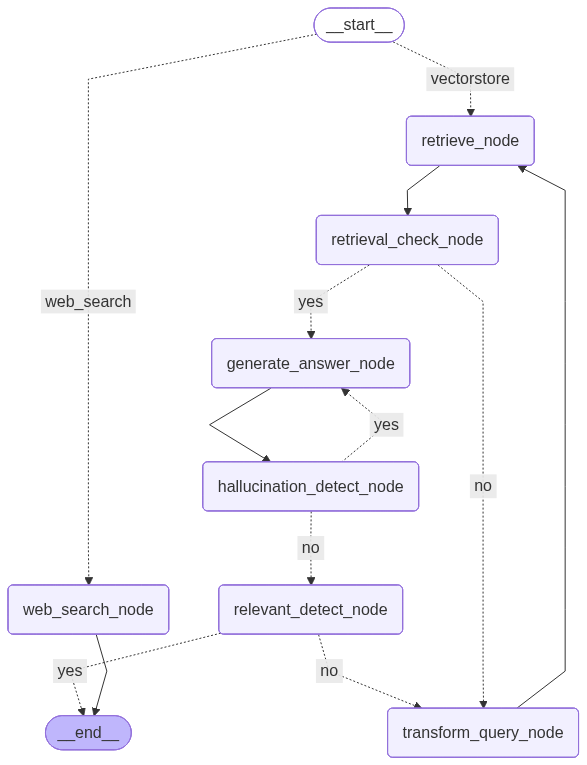

In [141]:
# 그래프 베이스 생성
workflow = StateGraph(AdaptiveRAGState)
# 노드 및 엣지 연결
workflow.add_node('retrieve_node',retrieve_node)
workflow.add_node('web_search_node',web_search_node)
workflow.add_conditional_edges(
    START,
    route_question,
    {
        'vectorstore' : 'retrieve_node',
        'web_search' : 'web_search_node'
    }
)
workflow.add_node('transform_query_node', transform_query_node)
workflow.add_node('retrieval_check_node', retrieval_check_node)
workflow.add_node('generate_answer_node', generate_answer_node)

workflow.add_edge('retrieve_node',"retrieval_check_node")
workflow.add_conditional_edges(
    "retrieval_check_node",
    route_retrieval_grade,
    {
        "yes" : "generate_answer_node",
        "no" : "transform_query_node"
    }
)
workflow.add_edge('transform_query_node',"retrieve_node")
# 할루시네이션 체크 part
workflow.add_node('hallucination_detect_node',hallucination_detect_node)
workflow.add_edge('generate_answer_node','hallucination_detect_node')
workflow.add_conditional_edges(
    'hallucination_detect_node',
    route_hallucination_check,
    {'yes' : "generate_answer_node", "no" : "relevant_detect_node"}
)
# 답변관련성 체크 part
workflow.add_node('relevant_detect_node', relevant_detect_node)
workflow.add_conditional_edges(
    'relevant_detect_node',
    route_relevant_check,
    {'yes' : END, "no" : "transform_query_node"}
)
workflow.add_edge('web_search_node',END)
# 컴파일
app = workflow.compile()
# 그래프 시각화
display(Image(app.get_graph().draw_mermaid_png()))

In [142]:
input = AdaptiveRAGState(
    question='삼성과 카카오가 만든 생성형 AI 이름은?',
    max_repeat_num=5,
    current_repeat_num=0
)
rs = app.invoke(input=input)

===[질문분석===]
===[질문을 vectorstore로 연결]===
====[문서검색]====
===[검색된 문서 수 : 5]===
====[문서관련성check]===
====[문서갯수 : 2]===
===[답변생성]===
===[할루시네이션check]===
===[답변관련성check]===
===[쿼리변환]====
====[문서검색]====
===[검색된 문서 수 : 5]===
====[문서관련성check]===
====[문서갯수 : 2]===
===[답변생성]===
===[할루시네이션check]===
===[할루시네이션 감지]===
===[답변생성]===
===[할루시네이션check]===
===[할루시네이션 감지]===
===[답변생성]===
===[할루시네이션check]===
===[할루시네이션 감지]===
===[답변생성]===
===[할루시네이션check]===
===[할루시네이션 감지]===
===[generate 횟수 초과]===
===[답변관련성check]===
===[답변관련성 문제 감지]===
===[query rewrite 횟수 초과]===


In [143]:
print(rs['answer'])

삼성과 카카오가 공동으로 개발한 생성형 AI의 이름은 '카나나(Kanana)'입니다.

**Source**
- "카카오는 동 브랜드를 자사가 개발하는 주요 AI 모델과 신규 서비스의 이름에 두루 사용할 계획으로..." 
- "AI 메이트 서비스를 ‘카나나’ 출시 계획도 공개" 
- (content/drive/MyDrive/AI/인사교_LangChain_20260624/data/SPRi AI Brief_11월호산ᅥᆸ동향.pdf, 페이지 13)
